In [1]:
import pandas as pd 

In [2]:
df1=pd.read_csv('jobs_feature_engineered.csv')

In [3]:
df=df1.copy()

In [5]:
df.shape

(7269, 74)

In [6]:
print("\nTarget column exists:", 'has_salary' in df.columns)


Target column exists: True


In [7]:
df.head()

,absolute_url,ai_opt_out_request_url,category,city,company_name,content_clean,contract_time,contract_type,created,created_date,...,title_has_senior,title_has_lead,title_has_manager,title_has_director,title_has_intern,title_has_junior,title_has_principal,title_has_staff,title_has_associate,salary_availability
0,https://www.adzuna.in/land/ad/5785772072?se=bi...,NaN,Engineering Jobs,Bangalore,ABB,"This job is with ABB, an inclusive employer an...",full_time,NaN,2026-07-03 00:54:22+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary
1,https://www.adzuna.in/land/ad/5794768004?se=bi...,NaN,IT Jobs,Bangalore,Kyndryl,"This job is with Kyndryl, an inclusive employe...",full_time,NaN,2026-07-10 03:46:23+00:00,2026-07-10,...,0,0,0,0,0,0,0,0,0,No salary
2,https://www.adzuna.in/land/ad/5785773087?se=bi...,NaN,IT Jobs,Hyderabad,Cornerstone OnDemand,"This job is with Cornerstone OnDemand, an incl...",full_time,NaN,2026-07-03 00:54:32+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary
3,https://www.adzuna.in/land/ad/5794153227?se=bi...,NaN,IT Jobs,Mumbai,Morningstar,"This job is with Morningstar, an inclusive emp...",full_time,NaN,2026-07-09 17:58:24+00:00,2026-07-09,...,0,0,0,0,0,0,0,0,0,No salary
4,https://www.adzuna.in/land/ad/5785771924?se=bi...,NaN,IT Jobs,Mumbai,Morningstar,"This job is with Morningstar, an inclusive emp...",full_time,NaN,2026-07-03 00:54:21+00:00,2026-07-03,...,0,0,0,0,0,0,0,0,0,No salary


In [9]:
df['has_salary'].value_counts()

has_salary
0    4653
1    2616
Name: count, dtype: int64

In [10]:
df['has_salary'].value_counts(normalize=True).mul(100).round(2)

has_salary
0    64.01
1    35.99
Name: proportion, dtype: float64

In [11]:
df['company_name'].nunique()

2505

In [12]:
df['company_name'].value_counts().describe()

count    2505.000000
mean        2.901796
std        17.844441
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       524.000000
Name: count, dtype: float64

In [14]:
(df['company_name'].value_counts() == 1).sum()

1836

In [15]:
source_salary = pd.crosstab(df['source'],df['has_salary'],normalize='index').mul(100).round(2)
print(source_salary)

has_salary      0      1
source                  
Adzuna      58.34  41.66
Greenhouse  76.23  23.77


In [16]:
pd.crosstab(df['source'],df['has_salary'])


has_salary,0,1
source,,
Adzuna,2896,2068
Greenhouse,1757,548


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# Create a combined stratification label
# This preserves both source and target proportions.
stratify_label = (
    df['source'].astype(str) + "_" + df['has_salary'].astype(str))

In [21]:
dev_df, final_holdout = train_test_split(df,test_size=0.20,random_state=123,stratify=stratify_label)

In [22]:
dev_df.shape

(5815, 74)

In [23]:
final_holdout.shape

(1454, 74)

In [24]:
pd.crosstab(dev_df['source'],dev_df['has_salary'],normalize='index').mul(100).round(2)

has_salary,0,1
source,,
Adzuna,58.35,41.65
Greenhouse,76.25,23.75


In [25]:
pd.crosstab(final_holdout['source'],final_holdout['has_salary'],normalize='index').mul(100).round(2)

has_salary,0,1
source,,
Adzuna,58.31,41.69
Greenhouse,76.14,23.86


In [27]:
salary_related_columns = [
    col for col in df.columns
    if any(keyword in col.lower()
        for keyword in ['salary','pay', 'fx', 'inr'])]

In [28]:
salary_related_columns

['other_market_salary_currency',
 'other_market_salary_max',
 'other_market_salary_min',
 'pay_transparency_max',
 'pay_transparency_min',
 'pay_transparency_unit',
 'salary_currency',
 'salary_max',
 'salary_min',
 'has_salary',
 'salary_range',
 'salary_mid',
 'has_salary_currency',
 'has_other_market_salary',
 'has_pay_transparency',
 'salary_range_pct',
 'salary_availability']

In [29]:
candidate_features = ['source', 'company_name','title','location_clean', 'city', 'state', 'category','contract_time',
    'contract_type','standard_role', 'posting_year',  'posting_month', 'title_word_count',  'title_length',
    'title_has_senior', 'title_has_lead','title_has_manager', 'title_has_director',
    'title_has_intern', 'title_has_junior','title_has_principal', 'title_has_staff', 'title_has_associate']


In [30]:
feature_check = pd.DataFrame({
    'missing': dev_df[candidate_features].isna().sum(),
    'unique_values': dev_df[candidate_features].nunique(dropna=True)}).sort_values('unique_values',ascending=False)


In [32]:
feature_check

,missing,unique_values
title,0,2417
company_name,0,2116
location_clean,6,591
title_length,0,85
city,2779,60
standard_role,1844,25
state,2760,23
category,1844,17
title_word_count,0,16
posting_month,0,12


In [33]:
core_features = [ 'source', 'category', 'standard_role','location_clean', 'posting_year', 'posting_month',
    'title_word_count', 'title_length', 'title_has_senior', 'title_has_lead','title_has_manager',
    'title_has_director','title_has_intern',  'title_has_junior','title_has_principal',
    'title_has_staff','title_has_associate']

In [34]:
X_dev = dev_df[core_features].copy()
y_dev = dev_df['has_salary'].copy()

In [35]:
print("X shape:", X_dev.shape)
print("y shape:", y_dev.shape)

X shape: (5815, 17)
y shape: (5815,)


In [36]:
X_dev.isna().sum()

source                    0
category               1844
standard_role          1844
location_clean            6
posting_year              0
posting_month             0
title_word_count          0
title_length              0
title_has_senior          0
title_has_lead            0
title_has_manager         0
title_has_director        0
title_has_intern          0
title_has_junior          0
title_has_principal       0
title_has_staff           0
title_has_associate       0
dtype: int64

In [37]:
print(core_features)

['source', 'category', 'standard_role', 'location_clean', 'posting_year', 'posting_month', 'title_word_count', 'title_length', 'title_has_senior', 'title_has_lead', 'title_has_manager', 'title_has_director', 'title_has_intern', 'title_has_junior', 'title_has_principal', 'title_has_staff', 'title_has_associate']


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [40]:
categorical_features = ['source','category','standard_role','location_clean']

numerical_features = [ 'posting_year','posting_month','title_word_count',
    'title_length','title_has_senior','title_has_lead','title_has_manager',
    'title_has_director','title_has_intern', 'title_has_junior','title_has_principal',
    'title_has_staff','title_has_associate']

In [41]:
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant',fill_value='Missing')),
        ('onehot',OneHotEncoder( handle_unknown='ignore', sparse_output=False))])

In [42]:
ml2_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline,categorical_features),
        ('numerical','passthrough', numerical_features)])

In [43]:
print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total input features:", len(categorical_features) + len(numerical_features))

Categorical features: 4
Numerical features: 13
Total input features: 17


In [50]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [51]:
# 1. Stratified cross-validation
stratified_cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

In [52]:
# 2. Baseline model
baseline_classifier = DummyClassifier(strategy='most_frequent')

In [53]:
# 3. Cross-validation predictions

baseline_pred = cross_val_predict(baseline_classifier,X_dev, y_dev, cv=stratified_cv,n_jobs=-1)


In [54]:
# 4. Metrics

baseline_accuracy = accuracy_score( y_dev,baseline_pred)

baseline_precision = precision_score(y_dev, baseline_pred,zero_division=0)

baseline_recall = recall_score(y_dev,baseline_pred,zero_division=0)

baseline_f1 = f1_score(y_dev, baseline_pred,zero_division=0)

In [55]:
print("ML-2 Classification Baseline")
print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1-score :", baseline_f1)

ML-2 Classification Baseline
Accuracy : 0.6402407566638005
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [69]:
# LogisticRegression

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
from sklearn.linear_model import LogisticRegression

In [63]:
stratified_cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

In [64]:
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant',fill_value='Missing')),
        ('onehot',OneHotEncoder( handle_unknown='ignore', sparse_output=False))])

numerical_pipeline_lr = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

In [65]:
preprocessor_lr = ColumnTransformer([
    ('cat', categorical_pipeline, categorical_features),
    ('num', numerical_pipeline_lr, numerical_features)])

In [66]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [67]:
lr_pred = cross_val_predict(logistic_pipeline,X_dev,y_dev,cv=stratified_cv,n_jobs=-1)

In [68]:
print("ML-2 Logistic Regression")
print("Accuracy :", accuracy_score(y_dev, lr_pred))
print("Precision:", precision_score(y_dev, lr_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, lr_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, lr_pred, zero_division=0))

ML-2 Logistic Regression
Accuracy : 0.7922613929492691
Precision: 0.7621589561091341
Recall   : 0.614244741873805
F1-score : 0.6802541026998412


In [77]:
# DecisionTreeClassifier

In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant',fill_value='Missing')),
        ('onehot',OneHotEncoder( handle_unknown='ignore', sparse_output=False))])

numerical_pipeline_tree = Pipeline([ ('imputer', SimpleImputer(strategy='median'))])

In [80]:
preprocessor_tree = ColumnTransformer([
    ('cat', categorical_pipeline, categorical_features),
    ('num', numerical_pipeline_tree, numerical_features)])

In [81]:
decision_tree_pipeline = Pipeline([('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=42))])

In [82]:
dt_pred = cross_val_predict(decision_tree_pipeline,X_dev, y_dev,cv=stratified_cv,n_jobs=-1)

In [83]:
print("ML-2 Decision Tree")
print("Accuracy :", accuracy_score(y_dev, dt_pred))
print("Precision:", precision_score(y_dev, dt_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, dt_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, dt_pred, zero_division=0))

ML-2 Decision Tree
Accuracy : 0.7900257953568358
Precision: 0.7293312269615587
Recall   : 0.6620458891013384
F1-score : 0.6940616386870458


In [85]:
from sklearn.ensemble import RandomForestClassifier

In [86]:
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant',fill_value='Missing')),
        ('onehot',OneHotEncoder( handle_unknown='ignore', sparse_output=False))])

numerical_pipeline_tree = Pipeline([ ('imputer', SimpleImputer(strategy='median'))])

In [87]:
preprocessor_tree = ColumnTransformer([
    ('cat', categorical_pipeline, categorical_features),
    ('num', numerical_pipeline_tree, numerical_features)])

In [88]:
random_forest_pipeline = Pipeline([('preprocessor', preprocessor_tree),
     ('model', RandomForestClassifier(n_estimators=300, random_state=42,n_jobs=-1))])

In [89]:
rf_pred = cross_val_predict(random_forest_pipeline,X_dev,y_dev,cv=stratified_cv,n_jobs=-1)

In [90]:
print("ML-2 Random Forest")
print("Accuracy :", accuracy_score(y_dev, rf_pred))
print("Precision:", precision_score(y_dev, rf_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, rf_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, rf_pred, zero_division=0))

ML-2 Random Forest
Accuracy : 0.7989681857265692
Precision: 0.7466595403527525
Recall   : 0.6677820267686424
F1-score : 0.7050214483976786


In [92]:
from xgboost import XGBClassifier

In [93]:
stratified_cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

In [94]:
categorical_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant',fill_value='Missing')),
        ('onehot',OneHotEncoder( handle_unknown='ignore', sparse_output=False))])

numerical_pipeline_tree = Pipeline([ ('imputer', SimpleImputer(strategy='median'))])

In [95]:
preprocessor_tree = ColumnTransformer([
    ('cat', categorical_pipeline, categorical_features),
    ('num', numerical_pipeline_tree, numerical_features)])

In [96]:
xgb_pipeline = Pipeline([('preprocessor', preprocessor_tree),
    ('model', XGBClassifier(n_estimators=300,max_depth=4, learning_rate=0.05,
        subsample=0.8,colsample_bytree=0.8,random_state=42,
        eval_metric='logloss',n_jobs=-1))])

In [97]:
xgb_pred = cross_val_predict(xgb_pipeline,X_dev,y_dev,cv=stratified_cv,n_jobs=-1)

In [98]:
print("ML-2 XGBoost")
print("Accuracy :", accuracy_score(y_dev, xgb_pred))
print("Precision:", precision_score(y_dev, xgb_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, xgb_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, xgb_pred, zero_division=0))

ML-2 XGBoost
Accuracy : 0.8180567497850387
Precision: 0.7654004106776181
Recall   : 0.7127151051625239
F1-score : 0.7381188118811881


In [ ]:
# tune XGBoost

In [99]:
from sklearn.model_selection import RandomizedSearchCV

In [100]:
xgb_search = RandomizedSearchCV(estimator=xgb_pipeline,
    param_distributions={'model__n_estimators': [200, 300, 400, 500],
        'model__max_depth': [2, 3, 4, 5, 6],
        'model__learning_rate': [0.03, 0.05, 0.08, 0.1],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0] },
    n_iter=25, scoring='f1',cv=stratified_cv, random_state=42,n_jobs=-1)

In [101]:
xgb_search.fit(X_dev, y_dev)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [102]:
print("Best F1:", xgb_search.best_score_)
print("Best Parameters:")
print(xgb_search.best_params_)

Best F1: 0.7425770445462215
Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.9}


In [105]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
         f1_score,roc_auc_score,confusion_matrix,classification_report)

In [106]:
# Prepare the locked final holdout
X_holdout = final_holdout[core_features].copy()
y_holdout = final_holdout['has_salary'].copy()

In [107]:
# Best model selected using development data only
final_xgb_model = xgb_search.best_estimator_

In [108]:
# Predict on the locked holdout
holdout_pred = final_xgb_model.predict(X_holdout)
holdout_prob = final_xgb_model.predict_proba(X_holdout)[:, 1]

In [109]:
print("ML-2 Final XGBoost Evaluation")
print("Accuracy :", accuracy_score(y_holdout, holdout_pred))
print("Precision:", precision_score(y_holdout, holdout_pred, zero_division=0))
print("Recall   :", recall_score(y_holdout, holdout_pred, zero_division=0))
print("F1-score :", f1_score(y_holdout, holdout_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_holdout, holdout_prob))

ML-2 Final XGBoost Evaluation
Accuracy : 0.8204951856946355
Precision: 0.7689161554192229
Recall   : 0.7175572519083969
F1-score : 0.7423494570582428
ROC-AUC  : 0.8907535089879339


In [110]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_holdout, holdout_pred))

print("\nClassification Report:")
print(classification_report(y_holdout, holdout_pred, zero_division=0))


Confusion Matrix:
[[817 113]
 [148 376]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       930
           1       0.77      0.72      0.74       524

    accuracy                           0.82      1454
   macro avg       0.81      0.80      0.80      1454
weighted avg       0.82      0.82      0.82      1454



In [111]:
source_only = X_dev[['source']].copy()

source_only_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('source', categorical_pipeline, ['source'])])),
    ('model', LogisticRegression(max_iter=2000, random_state=42))])

source_pred = cross_val_predict(source_only_pipeline, source_only, y_dev, cv=stratified_cv, n_jobs=-1)

In [112]:
print("ML-2 Source-Only Logistic Regression")
print("Accuracy :", accuracy_score(y_dev, source_pred))
print("Precision:", precision_score(y_dev, source_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, source_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, source_pred, zero_division=0))

ML-2 Source-Only Logistic Regression
Accuracy : 0.6402407566638005
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [113]:
source_prob = cross_val_predict(source_only_pipeline,source_only,y_dev, cv=stratified_cv,method='predict_proba',
    n_jobs=-1)[:, 1]

In [114]:
print("Source-only ROC-AUC:", roc_auc_score(y_dev, source_prob))

Source-only ROC-AUC: 0.5744220079922799


In [116]:
location_counts = X_dev['location_clean'].value_counts(dropna=False)

print("Number of unique locations:", X_dev['location_clean'].nunique(dropna=False))

Number of unique locations: 592


In [117]:
print("\nLocation frequency summary:")
print(location_counts.describe())


Location frequency summary:
count     592.000000
mean        9.822635
std        63.007323
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      1038.000000
Name: count, dtype: float64


In [118]:
print("\nLocations appearing only once:",
      (location_counts == 1).sum())

print("Locations appearing 2 times:",
      (location_counts == 2).sum())

print("Locations appearing <= 5 times:",
      (location_counts <= 5).sum())


Locations appearing only once: 352
Locations appearing 2 times: 83
Locations appearing <= 5 times: 504


In [119]:
location_only = X_dev[['location_clean']].copy()

In [120]:
location_only_pipeline = Pipeline([('preprocessor', ColumnTransformer([
        ('location', categorical_pipeline, ['location_clean'])])),
    ('model', LogisticRegression(max_iter=2000, random_state=42))])


In [121]:
location_prob = cross_val_predict(location_only_pipeline, location_only, y_dev,cv=stratified_cv,
                                  method='predict_proba',n_jobs=-1)[:, 1]

In [122]:
location_pred = (location_prob >= 0.5).astype(int)

In [123]:
print("ML-2 Location-Only Logistic Regression")
print("Accuracy :", accuracy_score(y_dev, location_pred))
print("Precision:", precision_score(y_dev, location_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, location_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, location_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_dev, location_prob))

ML-2 Location-Only Logistic Regression
Accuracy : 0.6526225279449699
Precision: 0.5708661417322834
Recall   : 0.13862332695984703
F1-score : 0.2230769230769231
ROC-AUC  : 0.6641867975876277


In [125]:
location_counts = X_dev['location_clean'].value_counts(dropna=False)

rare_locations = location_counts[location_counts < 5].index

location_collapsed = X_dev['location_clean'].copy()

location_collapsed = location_collapsed.where(~location_collapsed.isin(rare_locations), 'Other')



In [126]:
print("Original unique locations:",
      X_dev['location_clean'].nunique(dropna=False))

Original unique locations: 592


In [127]:
print("Collapsed unique locations:",
      location_collapsed.nunique(dropna=False))

Collapsed unique locations: 99


In [128]:
print("\nTop 10 locations after collapsing:")
print(location_collapsed.value_counts(dropna=False).head(10))


Top 10 locations after collapsing:
location_clean
Bangalore, Karnataka                        1038
India                                        924
Other                                        715
Mumbai, Maharashtra                          334
Hyderabad, Telangana                         330
Pune, Maharashtra                            318
Chennai, Tamil Nadu                          235
Delhi, India                                 147
Noida, Ghaziabad                             120
San Francisco, California, United States      85
Name: count, dtype: int64


In [129]:
location_minfreq_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('location', Pipeline([('imputer', SimpleImputer( strategy='constant',fill_value='Missing' )),
        ('onehot', OneHotEncoder( handle_unknown='ignore',min_frequency=5,sparse_output=False ))]), ['location_clean']) ])),
        ('model', LogisticRegression(max_iter=2000,random_state=42))])

In [130]:
location_minfreq_prob = cross_val_predict(location_minfreq_pipeline,
    X_dev[['location_clean']],y_dev, cv=stratified_cv,method='predict_proba',
    n_jobs=-1)[:, 1]

In [131]:
location_minfreq_pred = (location_minfreq_prob >= 0.5).astype(int)

In [132]:
print("ML-2 Location-Only Logistic Regression")
print("Rare categories grouped with min_frequency=5")
print("Accuracy :", accuracy_score(y_dev, location_minfreq_pred))
print("Precision:", precision_score(y_dev, location_minfreq_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, location_minfreq_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, location_minfreq_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_dev, location_minfreq_prob))


ML-2 Location-Only Logistic Regression
Rare categories grouped with min_frequency=5
Accuracy : 0.6526225279449699
Precision: 0.5705882352941176
Recall   : 0.13910133843212238
F1-score : 0.22367409684857803
ROC-AUC  : 0.6580042976094547


In [133]:
for col in ['category', 'standard_role']:
    print(f"\n===== {col} =====")
    missing_summary = (dev_df.assign(is_missing=dev_df[col].isna())
        .groupby(['source', 'is_missing'])['has_salary']
        .agg(['count', 'mean'])
        .reset_index())
    print(missing_summary)


===== category =====
       source  is_missing  count      mean
0      Adzuna       False   3971  0.416520
1  Greenhouse        True   1844  0.237527

===== standard_role =====
       source  is_missing  count      mean
0      Adzuna       False   3971  0.416520
1  Greenhouse        True   1844  0.237527


In [134]:
features_without_cat_role = [ 'source', 'location_clean','posting_year','posting_month','title_word_count',
    'title_length','title_has_senior', 'title_has_lead','title_has_manager', 'title_has_director',
    'title_has_intern', 'title_has_junior','title_has_principal', 'title_has_staff','title_has_associate']


In [135]:
X_dev_reduced = dev_df[features_without_cat_role].copy()

In [136]:
categorical_reduced = ['source','location_clean']

numerical_reduced = ['posting_year','posting_month', 'title_word_count','title_length',
    'title_has_senior','title_has_lead','title_has_manager','title_has_director',
    'title_has_intern','title_has_junior','title_has_principal','title_has_staff',
    'title_has_associate']

In [137]:
preprocessor_reduced = ColumnTransformer([
    ('cat', categorical_pipeline, categorical_reduced),
    ('num', numerical_pipeline_tree, numerical_reduced)])


In [138]:
xgb_reduced_pipeline = Pipeline([
    ('preprocessor', preprocessor_reduced),
    ('model', XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,
        subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric='logloss',
        n_jobs=-1 ))])

In [139]:
reduced_prob = cross_val_predict(xgb_reduced_pipeline, X_dev_reduced,y_dev,cv=stratified_cv,method='predict_proba',n_jobs=-1)[:, 1]

In [140]:
reduced_pred = (reduced_prob >= 0.5).astype(int)

In [141]:
print("XGBoost without category + standard_role")
print("Accuracy :", accuracy_score(y_dev, reduced_pred))
print("Precision:", precision_score(y_dev, reduced_pred, zero_division=0))
print("Recall   :", recall_score(y_dev, reduced_pred, zero_division=0))
print("F1-score :", f1_score(y_dev, reduced_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_dev, reduced_prob))

XGBoost without category + standard_role
Accuracy : 0.8166809974204643
Precision: 0.7575301204819277
Recall   : 0.72131931166348
F1-score : 0.7389813907933399
ROC-AUC  : 0.8879805215781801


In [142]:
rf_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions={
        'model__n_estimators': [200, 300, 400, 500],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None] },
    n_iter=25,
    scoring='f1',
    cv=stratified_cv,
    random_state=42,
    n_jobs=-1)

In [143]:
rf_search.fit(X_dev, y_dev)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation s

In [144]:
print("Best Random Forest F1:", rf_search.best_score_)
print("Best Parameters:")
print(rf_search.best_params_)

Best Random Forest F1: 0.7346409868703495
Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 5}


In [145]:
# Get feature names after preprocessing
feature_names = (final_xgb_model.named_steps['preprocessor'].get_feature_names_out())

# Get XGBoost feature importance
importance_values = (final_xgb_model.named_steps['model'].feature_importances_)

# Create a table
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values})

# Sort from most important to least important
feature_importance = feature_importance.sort_values('importance',ascending=False)

print("Top 20 XGBoost Features:")
print(feature_importance.head(20).to_string(index=False))

Top 20 XGBoost Features:
                                                             feature  importance
                                                   num__posting_year    0.165247
                                               cat__category_IT Jobs    0.081913
                                              cat__source_Greenhouse    0.049693
                                                  cat__source_Adzuna    0.044677
                                                  num__posting_month    0.022251
                               cat__standard_role_Frontend Developer    0.018738
                                      cat__category_Engineering Jobs    0.018343
                                                   num__title_length    0.016865
                         cat__location_clean_New York, New York, USA    0.016761
                             cat__standard_role_Full Stack Developer    0.016632
                                                num__title_has_staff    0.016581
   

In [148]:
categorical_features_all = ['source','category','standard_role','location_clean']

numerical_features_all = [ 'posting_year', 'posting_month','title_word_count','title_length',
    'title_has_senior', 'title_has_lead','title_has_manager','title_has_director', 'title_has_intern',
    'title_has_junior', 'title_has_principal',  'title_has_staff','title_has_associate']

In [149]:
def get_original_feature(encoded_name):
    for feature in categorical_features_all:
        prefix = f'cat__{feature}_'
        if encoded_name.startswith(prefix):
            return feature
    
    for feature in numerical_features_all:
        if encoded_name == f'num__{feature}':
            return feature
    
    return encoded_name

In [150]:
feature_importance['original_feature'] = ( feature_importance['feature'].apply(get_original_feature))


In [151]:
aggregated_importance = (feature_importance
    .groupby('original_feature', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False))

In [152]:
print("Aggregated Feature Importance:")
print(aggregated_importance.to_string(index=False))

Aggregated Feature Importance:
   original_feature  importance
     location_clean    0.389986
       posting_year    0.165247
      standard_role    0.143600
           category    0.101579
             source    0.094370
      posting_month    0.022251
       title_length    0.016865
    title_has_staff    0.016581
   title_word_count    0.011165
title_has_associate    0.010654
     title_has_lead    0.008446
  title_has_manager    0.008107
   title_has_senior    0.006177
 title_has_director    0.004972
   title_has_junior    0.000000
title_has_principal    0.000000
   title_has_intern    0.000000


In [154]:
import numpy as np
from sklearn.model_selection import cross_val_predict

# Out-of-fold probabilities on development data
xgb_oof_prob = cross_val_predict(xgb_search.best_estimator_,
    X_dev,y_dev, cv=stratified_cv,method='predict_proba',
    n_jobs=-1)[:, 1]

In [155]:
thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    pred = (xgb_oof_prob >= threshold).astype(int)

    threshold_results.append({
        'threshold': round(threshold, 2),
        'precision': precision_score(y_dev, pred, zero_division=0),
        'recall': recall_score(y_dev, pred, zero_division=0),
        'f1': f1_score(y_dev, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)


In [156]:
print(threshold_results.to_string(index=False))

 threshold  precision   recall       f1
      0.30   0.676875 0.824092 0.743264
      0.35   0.707706 0.785851 0.744734
      0.40   0.726492 0.768164 0.746747
      0.45   0.748319 0.744742 0.746526
      0.50   0.769073 0.717973 0.742645
      0.55   0.796601 0.672084 0.729064
      0.60   0.836775 0.600382 0.699137
      0.65   0.866815 0.556883 0.678114
      0.70   0.885618 0.503346 0.641877


In [157]:
import joblib

joblib.dump(
    final_xgb_model,
    "salary_availability_xgb_model.pkl"
)

print("ML-2 final model saved successfully.")

ML-2 final model saved successfully.


In [158]:
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

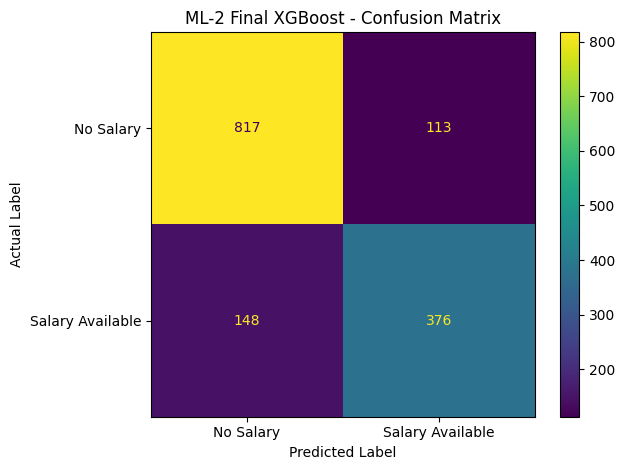

In [160]:
ConfusionMatrixDisplay.from_predictions(y_holdout,holdout_pred,display_labels=['No Salary', 'Salary Available'])
plt.title("ML-2 Final XGBoost - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

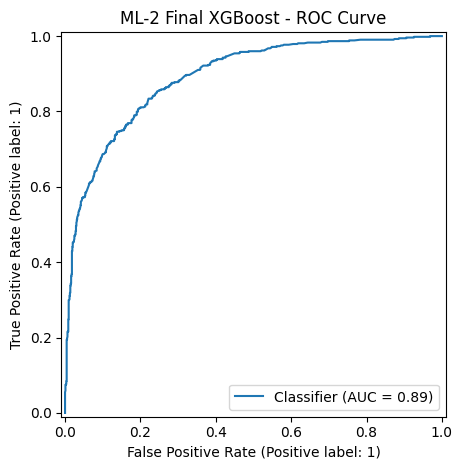

In [161]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions( y_holdout, holdout_prob)
plt.title("ML-2 Final XGBoost - ROC Curve")
plt.tight_layout()
plt.show()

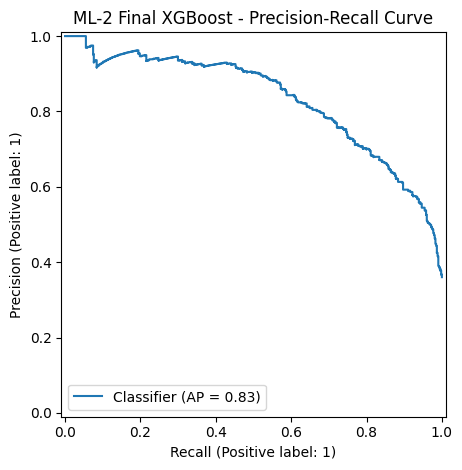

In [162]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_holdout,holdout_prob)
plt.title("ML-2 Final XGBoost - Precision-Recall Curve")
plt.tight_layout()
plt.show()

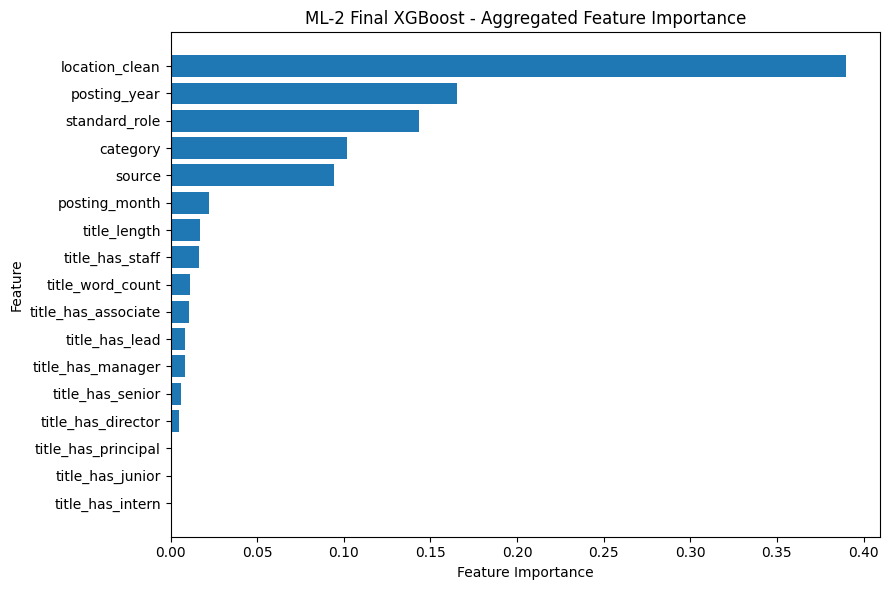

In [163]:
plot_data = (aggregated_importance.sort_values('importance', ascending=True))

plt.figure(figsize=(9, 6))
plt.barh(plot_data['original_feature'],plot_data['importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("ML-2 Final XGBoost - Aggregated Feature Importance")

plt.tight_layout()
plt.show()

## ML-2: Salary Availability Prediction — Conclusion

The objective of ML-2 was to predict whether a job posting contains salary information using the binary target variable `has_salary`.

### Target Distribution

The target variable was moderately imbalanced:

- `0` — No salary information: 64.01%
- `1` — Salary available: 35.99%

### Evaluation Strategy

The dataset was divided into:

- Development set: 5,815 records
- Final holdout set: 1,454 records

The development set was used for model comparison and hyperparameter tuning using 5-fold Stratified Cross-Validation. Stratification was used to preserve the class distribution across the folds.

The final holdout set was kept locked during model development and was used only once for the final evaluation of the selected model.

### Models Evaluated

The following models were evaluated:

1. Dummy Classifier — baseline
2. Logistic Regression
3. Decision Tree
4. Random Forest
5. XGBoost

Random Forest and XGBoost were additionally tuned using `RandomizedSearchCV` on the development set.

### Development Cross-Validation Results

| Model | F1-score |
|---|---:|
| Dummy Classifier | 0.0000 |
| Logistic Regression | 0.6803 |
| Decision Tree | 0.6941 |
| Random Forest | 0.7050 |
| Tuned Random Forest | 0.7346 |
| XGBoost | 0.7381 |
| Tuned XGBoost | 0.7426 |

The tuned XGBoost model achieved the highest development cross-validation F1-score.

The selected XGBoost parameters were:

- `n_estimators = 300`
- `max_depth = 5`
- `learning_rate = 0.03`
- `subsample = 1.0`
- `colsample_bytree = 0.9`

### Final Holdout Evaluation

The selected tuned XGBoost model was evaluated on the locked 1,454-record final holdout set.

The final performance was:

- **Accuracy:** 82.05%
- **Precision:** 76.89%
- **Recall:** 71.76%
- **F1-score:** 74.23%
- **ROC-AUC:** 89.08%
- **Average Precision:** approximately 0.83

The confusion matrix was:

| | Predicted: No Salary | Predicted: Salary Available |
|---|---:|---:|
| Actual: No Salary | 817 | 113 |
| Actual: Salary Available | 148 | 376 |

Therefore:

- True Negatives = 817
- False Positives = 113
- False Negatives = 148
- True Positives = 376

### Feature Analysis

Aggregated feature importance from the final XGBoost model showed that the main predictive feature groups were:

- `location_clean`: 0.3900
- `posting_year`: 0.1652
- `standard_role`: 0.1436
- `category`: 0.1016
- `source`: 0.0944

Together, these five feature groups accounted for approximately 89.5% of the total aggregated feature importance.

Additional experiments were performed to understand the contribution of individual features.

`source` alone produced a ROC-AUC of 0.5744, showing that source contains some predictive information but is not sufficient by itself.

`location_clean` alone produced a ROC-AUC of 0.6642. Because many location categories were rare, rare-category grouping using `min_frequency=5` was tested. This reduced the location-only ROC-AUC to 0.6580, so the original location representation was retained.

`category` and `standard_role` were missing for all Greenhouse records in the development data, making their missingness closely tied to `source`. An ablation experiment removing these two features produced a development cross-validation F1-score of 0.7390, compared with 0.7381 for the corresponding full-feature XGBoost experiment. The evaluated final model retained these features for consistency with the validated feature set; they may be reconsidered in a future production iteration if these fields remain systematically incomplete.

Feature importance represents the predictive contribution of variables within the fitted model. It does not establish that any feature causes salary disclosure or withholding.

### Threshold Analysis

The final holdout evaluation used the default classification threshold of 0.50.

Development out-of-fold threshold analysis showed the expected precision-recall trade-off. Lowering the threshold increased recall while reducing precision, whereas increasing the threshold increased precision while reducing recall.

The highest observed development F1-score was approximately 0.7467 at a threshold of 0.40, compared with approximately 0.7426 at the default threshold of 0.50.

This threshold analysis was performed using development out-of-fold predictions only. The final holdout result was retained at the 0.50 threshold and was not changed based on the holdout results.

### Overall Conclusion

The ML-2 experiments show that job-posting metadata can be used to predict whether salary information is available. The tuned XGBoost classifier achieved **82.05% accuracy, 76.89% precision, 71.76% recall, 74.23% F1-score, and 89.08% ROC-AUC** on the locked final holdout set.

The feature analysis indicates that `location_clean`, `posting_year`, `standard_role`, `category`, and `source` were the main contributors to the model's predictions. The model therefore uses information from multiple job-posting attributes rather than relying on `source` alone.

The model can be used as a predictive component of the Job Market Intelligence Dashboard to estimate whether a job posting is likely to contain salary information. These predictions should be interpreted as statistical model outputs rather than causal explanations of employer behavior.

### Limitations

- Salary availability patterns may differ across data sources.
- Several categorical fields are systematically incomplete for some sources.
- `location_clean` contains many rare categories.
- The dataset represents the available historical job postings and may not generalize equally to future postings or new sources.
- Feature importance describes model behavior and should not be interpreted causally.
- Different classification thresholds produce different precision-recall trade-offs.